In [1]:
import pandas as pd

df = pd.read_excel("Global_Superstore2.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [3]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

categorical_cols = [
    "Category",
    "Region",
    "Segment",
    "Ship Mode",
    "Market"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [4]:
X = df[
    [
        "Category",
        "Region",
        "Segment",
        "Quantity",
        "Discount",
        "Shipping Cost"
    ]
]

y = df["Sales"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(41032, 6)
(10258, 6)


In [6]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[  8.25953      7.49779333 114.59263     24.503276     9.784468
 134.37611    323.08344    101.36387     16.040088    23.14391   ]


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

MAE : 109.79
RMSE: 289.02
R² Score: 0.6267


         Feature  Importance
5  Shipping Cost    0.785170
3       Quantity    0.069378
1         Region    0.052995
4       Discount    0.043244
2        Segment    0.026244
0       Category    0.022969


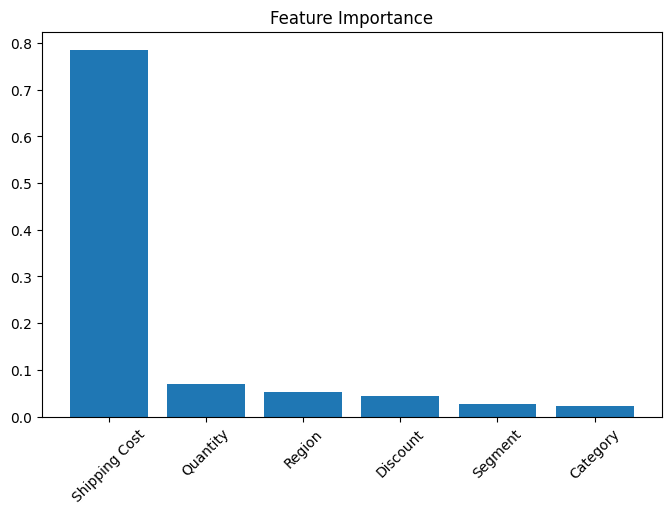

In [9]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [10]:
import joblib
joblib.dump(
    model,
    "sales_prediction_model.pkl",
    compress=3
)

['sales_prediction_model.pkl']

In [11]:
import sys
print(sys.executable)

C:\Users\shafi\anaconda3\python.exe


In [12]:
import joblib

encoders = joblib.load("encoders.pkl")

print(type(encoders))
print(encoders)


<class 'dict'>
{'Category': LabelEncoder(), 'Region': LabelEncoder(), 'Segment': LabelEncoder(), 'Ship Mode': LabelEncoder(), 'Market': LabelEncoder()}


In [13]:
print(type(encoders["Category"]))
print(encoders["Category"])

<class 'sklearn.preprocessing._label.LabelEncoder'>
LabelEncoder()


In [14]:
print(encoders["Category"].classes_)

['Furniture' 'Office Supplies' 'Technology']


In [15]:
print(df["Category"].dtype)
print(df["Region"].dtype)
print(df["Segment"].dtype)

int64
int64
int64


In [16]:
import os

size = os.path.getsize("sales_prediction_model.pkl") / (1024 * 1024)
print(f"Model size: {size:.2f} MB")


Model size: 78.32 MB
